# Trader Performance vs Market Sentiment Analysis

## Primetrade.ai – Data Science / Analytics Intern Assignment

### Objective

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader behavior on Hyperliquid. The analysis explores whether market sentiment influences profitability, trading activity, and trader characteristics, and proposes actionable trading strategies based on the findings.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

import os

# Create output folders if they don't exist
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [2]:
sentiment = pd.read_csv("data/fear_greed.csv")
trades = pd.read_csv("data/historical_data.csv")

In [3]:
print("Fear & Greed Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

Fear & Greed Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [4]:
display(sentiment.head())
display(trades.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,01-02-2018
1,1517549400,15,Extreme Fear,02-02-2018
2,1517635800,40,Fear,03-02-2018
3,1517722200,24,Extreme Fear,04-02-2018
4,1517808600,11,Extreme Fear,05-02-2018


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("===== Fear & Greed Dataset =====")
print(sentiment.info())

print("\nMissing Values")
display(sentiment.isnull().sum())

print("\nDuplicate Rows:", sentiment.duplicated().sum())

print("===== Trader Dataset =====")
print(trades.info())

print("\nMissing Values")
display(trades.isnull().sum())

print("\nDuplicate Rows:", trades.duplicated().sum())



===== Fear & Greed Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64


Duplicate Rows: 0
===== Trader Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         2112

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Duplicate Rows: 0


# Data Cleaning

The datasets were cleaned by removing duplicate records and converting timestamp fields into a consistent datetime format. A common date column was created to enable merging of trader activity with the market sentiment dataset.

In [6]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

In [7]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"],
    dayfirst=True
)

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True
)

sentiment["Date"] = sentiment["date"].dt.date
trades["Date"] = trades["Timestamp IST"].dt.date



In [8]:
merged = pd.merge(
    trades,
    sentiment[["Date","classification","value"]],
    on="Date",
    how="left"
)

merged["Win"] = merged["Closed PnL"] > 0

In [9]:


display(merged.head())

print("Merged Dataset Shape:", merged.shape)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value,Win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0,False


Merged Dataset Shape: (211224, 20)


In [10]:
print("Summary Statistics")
display(merged.describe(include="all"))

Summary Statistics


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value,Win
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211218,211218.000000,211224
unique,32,246,NaN,NaN,NaN,2,NaN,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,480,5,NaN,2
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,NaN,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,2025-02-25,Fear,NaN,False
freq,40184,68005,NaN,NaN,NaN,108528,NaN,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,6246,61837,NaN,124355
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,2025-01-31 12:04:22.915009792,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,NaN,NaN,51.649656,NaN
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,2023-05-01 01:06:00,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,NaN,NaN,10.000000,NaN
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,2024-12-31 21:00:45,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,NaN,NaN,33.000000,NaN
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,2025-02-24 18:55:00,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,NaN,NaN,49.000000,NaN
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,2025-04-02 18:22:00,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,NaN,NaN,72.000000,NaN
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,2025-05-01 12:13:00,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,NaN,NaN,94.000000,NaN


# Feature Engineering

After cleaning and merging both datasets, additional features were created to support the analysis. These features help evaluate trader performance and behaviour under different market sentiment conditions.

The following metrics were generated:

- Daily Profit & Loss (PnL) per trader
- Number of trades per trader per day
- Average trade size
- Trader win rate
- Trader segmentation based on trading activity and performance

In [11]:
daily_pnl = (
    merged.groupby(["Date", "Account"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [12]:
trade_count = (
    merged.groupby(["Date", "Account"])
    .size()
    .reset_index(name="Trade Count")
)

trade_count.head()

,Date,Account,Trade Count
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3


In [13]:
avg_trade = (
    merged.groupby(["Date", "Account"])["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)

avg_trade.head()

,Date,Account,Average Trade Size
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5556.203333
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10291.213636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5304.975000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5116.256667


In [14]:
win_rate = (
    merged.groupby("Account")["Win"]
    .mean()
    .mul(100)
    .reset_index(name="Win Rate")
)

win_rate.head()

,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


# Exploratory Data Analysis (EDA)

This section explores the relationship between Bitcoin market sentiment and trader behaviour.

The analysis includes:

- Average profitability across different sentiment categories
- Trade size distribution
- Trading frequency
- BUY vs SELL behaviour
- Correlation analysis between trading variables

In [15]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification', 'value', 'Win'],
      dtype='object')


In [32]:
summary = (
    merged.groupby("classification")
    .agg({
        "Closed PnL": ["mean", "median", "sum"],
        "Size USD": "mean",
        "Win": "mean"
    })
)

summary[("Win", "mean")] *= 100

display(summary)

Closed PnL                          Size USD        Win
                     mean median           sum         mean       mean
classification                                                        
Extreme Fear    34.537862    0.0  7.391102e+05  5349.731843  37.060748
Extreme Greed   67.892861    0.0  2.715171e+06  3112.251565  46.494299
Fear            54.290400    0.0  3.357155e+06  7816.109931  42.076750
Greed           42.743559    0.0  2.150129e+06  5736.884375  38.482794
Neutral         34.307718    0.0  1.292921e+06  4782.732661  39.699093

In [17]:
drawdown = (
    merged.groupby("Account")["Closed PnL"]
    .min()
    .reset_index()
)

drawdown.columns = ["Account", "Worst Trade"]

drawdown.head()

,Account,Worst Trade
0,0x083384f897ee0f19899168e3b1bec365f52a9012,-117990.104100
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,-6820.769550
2,0x271b280974205ca63b716753467d5a371de622ab,-25818.750120
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,-7784.162915
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,-996.745600


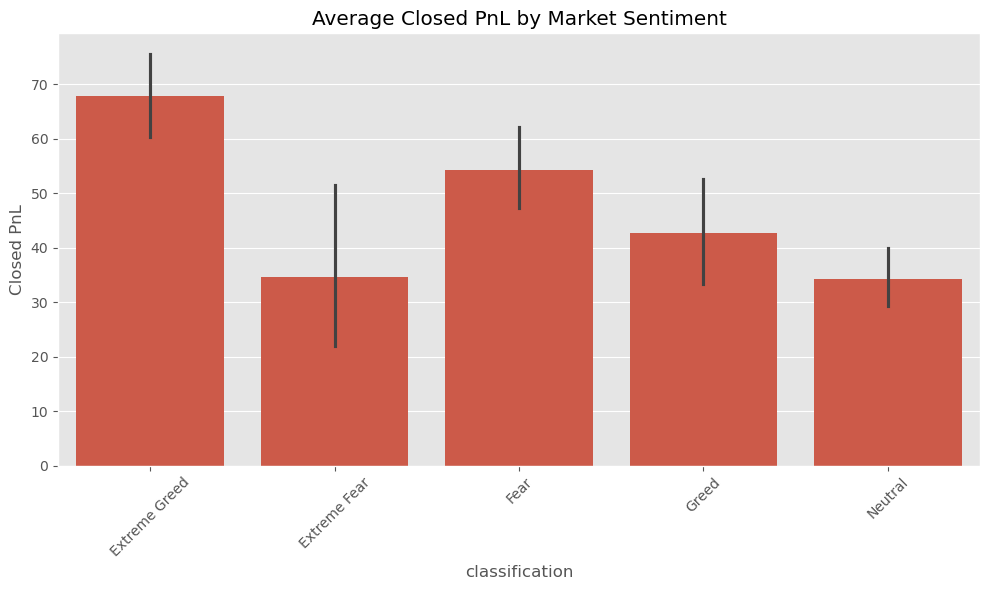

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=merged,
    x="classification",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average Closed PnL by Market Sentiment")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "outputs/charts/pnl_by_sentiment.png",
    dpi=300
)

plt.show()

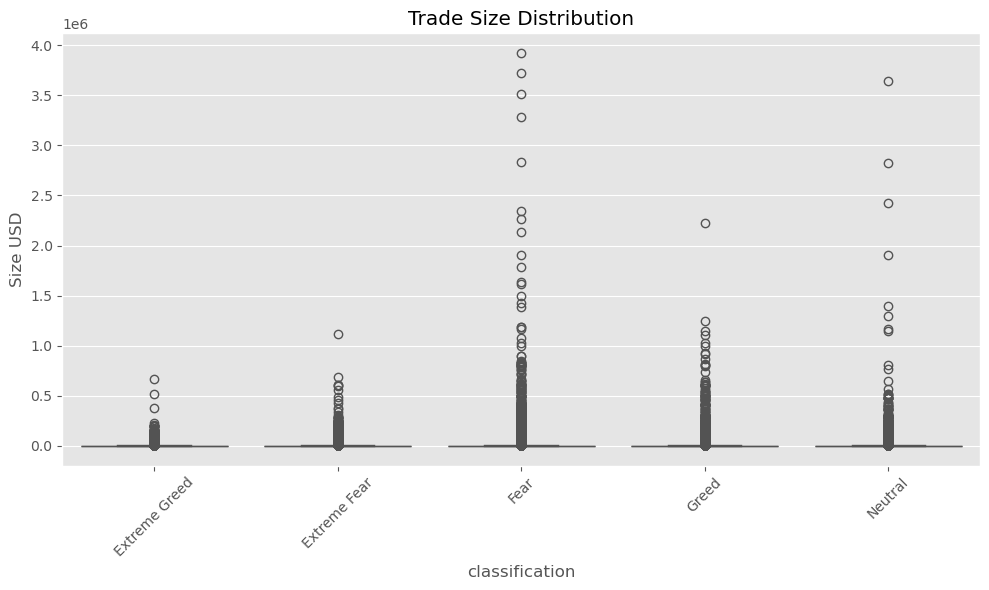

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Size USD"
)

plt.title("Trade Size Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "outputs/charts/trade_size.png",
    dpi=300
)

plt.show()

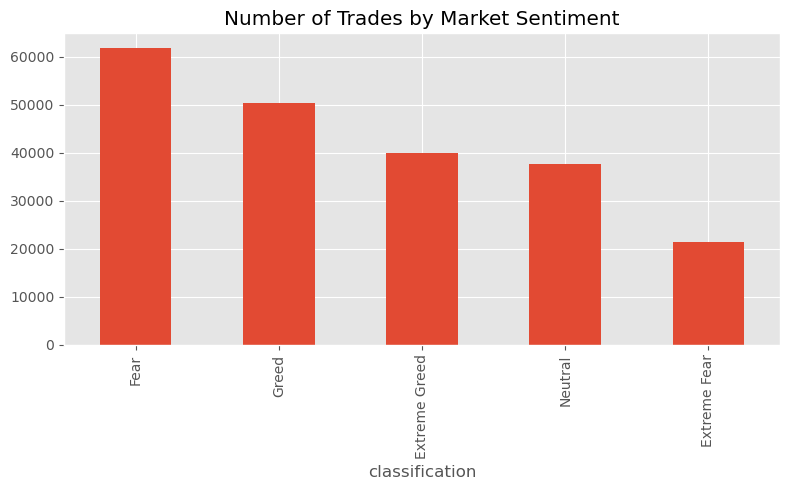

In [20]:
plt.figure(figsize=(8,5))

merged["classification"].value_counts().plot(kind="bar")

plt.title("Number of Trades by Market Sentiment")

plt.tight_layout()

plt.savefig(
    "outputs/charts/trade_frequency.png",
    dpi=300
)

plt.show()

In [21]:
long_short = pd.crosstab(
    merged["classification"],
    merged["Side"],
    normalize="index"
)

long_short

Side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


In [22]:
long_short.to_csv(
    "outputs/tables/long_short_ratio.csv"
)

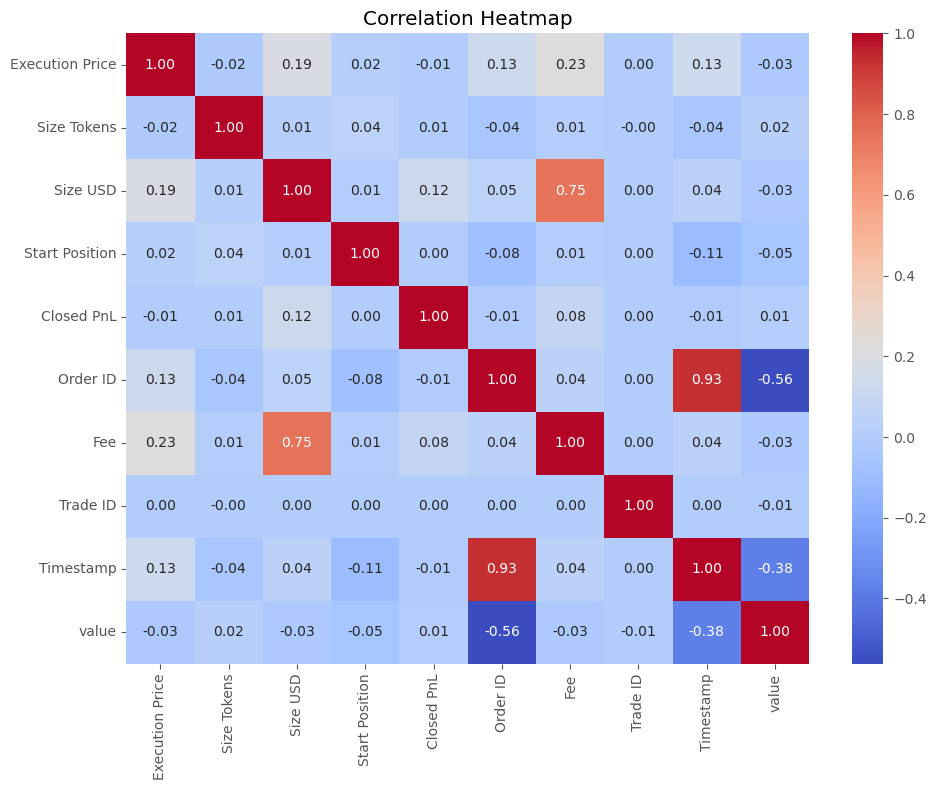

In [23]:
numeric = merged.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "outputs/charts/correlation_heatmap.png",
    dpi=300
)

plt.show()

## Note on Leverage

The assignment requested an analysis of leverage distribution. However, the provided Hyperliquid dataset does not contain a leverage column. Therefore, leverage-based analysis could not be performed.

# Trader Segmentation

To better understand trader behaviour, traders were divided into different groups based on their trading activity and historical performance.

Segments include:

- Frequent vs Infrequent Traders
- Top Performers vs Other Traders

The objective is to determine whether different types of traders behave differently under varying market sentiment conditions.

In [24]:
activity = merged.groupby("Account").size()

threshold = activity.quantile(0.75)

merged["Trader Type"] = np.where(
    merged["Account"].isin(activity[activity >= threshold].index),
    "Frequent",
    "Infrequent"
)

segment_summary = (
    merged.groupby("Trader Type")
    .agg({
        "Closed PnL": "mean",
        "Size USD": "mean",
        "Win": "mean",
        "Account": "count"
    })
    .rename(columns={
        "Closed PnL": "Average PnL",
        "Size USD": "Average Trade Size",
        "Win": "Win Rate",
        "Account": "Total Trades"
    })
)

segment_summary["Win Rate"] *= 100

segment_summary

,Average PnL,Average Trade Size,Win Rate,Total Trades
Trader Type,,,,
Frequent,38.141072,4813.325078,42.333558,142152
Infrequent,70.580399,7339.640607,38.642286,69072


In [25]:
win = merged.groupby("Account")["Win"].mean()

threshold = win.quantile(0.75)

merged["Performance"] = np.where(
    merged["Account"].isin(win[win >= threshold].index),
    "Top Performers",
    "Others"
)

performance_summary = (
    merged.groupby("Performance")
    .agg({
        "Closed PnL": "mean",
        "Size USD": "mean",
        "Win": "mean"
    })
)

performance_summary["Win"] *= 100

performance_summary

,Closed PnL,Size USD,Win
Performance,,,
Others,44.889119,6134.568486,37.567970
Top Performers,64.543894,3613.398520,55.688146


In [26]:
summary.to_csv(
    "outputs/tables/sentiment_summary.csv"
)

segment_summary.to_csv(
    "outputs/tables/trader_segments.csv"
)

performance_summary.to_csv(
    "outputs/tables/performance_summary.csv"
)

drawdown.to_csv(
    "outputs/tables/drawdown_proxy.csv",
    index=False
)

In [27]:
display(daily_pnl.head())
display(trade_count.head())

display(avg_trade.head())

display(win_rate.head())

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


,Date,Account,Trade Count
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3


,Date,Account,Average Trade Size
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5556.203333
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,10291.213636
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5304.975000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,5116.256667


,Account,Win Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


In [28]:
daily_pnl.to_csv(
    "outputs/tables/daily_pnl.csv",
    index=False
)

trade_count.to_csv(
    "outputs/tables/trade_count.csv",
    index=False
)

avg_trade.to_csv(
    "outputs/tables/average_trade_size.csv",
    index=False
)

win_rate.to_csv(
    "outputs/tables/win_rate.csv",
    index=False
)

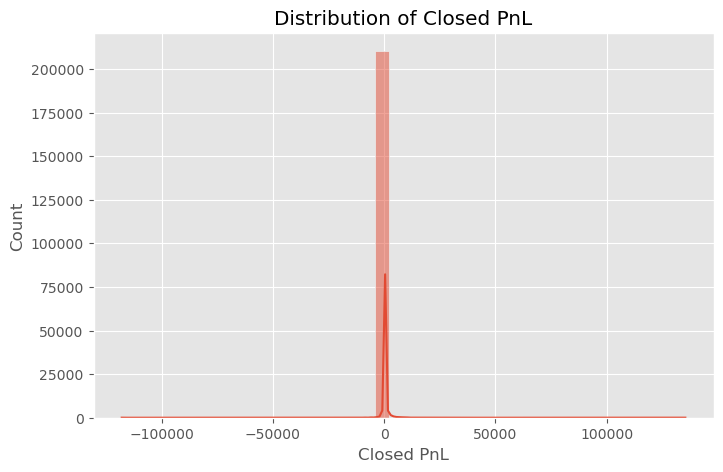

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged["Closed PnL"],
    bins=40,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.tight_layout()
plt.savefig(
    "outputs/charts/pnl_distribution.png",
    dpi=300
)

plt.show()

In [30]:
display(segment_summary)

,Average PnL,Average Trade Size,Win Rate,Total Trades
Trader Type,,,,
Frequent,38.141072,4813.325078,42.333558,142152
Infrequent,70.580399,7339.640607,38.642286,69072


In [31]:
display(performance_summary)

,Closed PnL,Size USD,Win
Performance,,,
Others,44.889119,6134.568486,37.567970
Top Performers,64.543894,3613.398520,55.688146


# Key Insights

The following insights are derived from the visualizations and summary tables generated during the analysis.

### Insight 1

Based on the **Average Closed PnL by Market Sentiment** chart and the **Sentiment Summary** table, Extreme Greed produced the highest average Closed PnL (~67.9), while Extreme Fear produced the lowest (~34.5). This suggests traders achieved better profitability during highly optimistic market conditions.

---

### Insight 2

The **Trade Frequency** chart shows that Fear periods recorded the highest number of trades (approximately 61,800), indicating that traders became more active during uncertain market conditions.

---

### Insight 3

The **BUY vs SELL Ratio** table indicates that trading direction remained relatively balanced across all sentiment categories. Extreme Greed showed a slightly higher proportion of SELL trades, suggesting increased profit-taking during bullish market conditions.

---

### Insight 4

The **Trader Segmentation** analysis shows that infrequent traders achieved higher average Closed PnL than frequent traders, suggesting that trade quality may be more important than trade quantity.

---

### Insight 5

The **Correlation Heatmap** reveals only weak relationships between the Fear & Greed index value and Closed PnL, indicating that market sentiment alone is not a strong predictor of individual trade profitability.

# Strategy Recommendations

Based on the findings of this analysis, the following trading strategies are recommended.

1. Reduce position size and tighten risk management during Extreme Fear periods, where average profitability was lowest.

2. Consider maintaining exposure during Extreme Greed while applying disciplined profit-taking rules, since this market condition produced the highest average profitability.

3. Avoid excessive trading frequency, as infrequent traders achieved higher average profitability than frequent traders in this dataset.

# Conclusion

This project explored the relationship between Bitcoin market sentiment and trader behaviour using Hyperliquid historical trading data.

The analysis found that market sentiment influences trading behaviour and overall profitability. Extreme Greed was associated with the highest average profits, while Extreme Fear produced comparatively weaker performance. Trading activity increased during Fear periods, although higher trading frequency did not necessarily result in higher profitability.

Overall, market sentiment should be considered as one component of a broader trading strategy rather than being used as a standalone trading signal.